In this notebook, Extended Kalman Filter is introduced to estimate dynamic system's state, espescially Kitti dataset.

In [1]:
import sys
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
sys.path.append('/app/src')
from data_loader import DataLoader
from configs import MeasurementDataEnum, SetupEnum, ErrorEnum, Configs, NoiseTypeEnum, FilterEnum
from kalman_filters import ExtendedKalmanFilter

%matplotlib inline
np.random.seed(777)

- [Extended description](#Extended-Kalman-filter)
- [Load data](#Load-raw-data-0033)
- [Data visualization](#Display-data-with-noise)
- [Applying Extended Kalman filter](#Applying-Extended-Kalman-Filter)
    - [Setup1](#Setup1-(IMU-input-->-EKF-with-Visual-Odometry-measurement))
        - [Setup1 result](#Setup1-Result)
    - [Setup2](#Setup2-(IMU-input-->-EKF-with-Visual-Odometry-and-GPS-measurement))
        - [Setup2 result](#Setup2-Result)
    - [Setup3](#Setup3-(INS-input-->-EKF-with-Visual-Odometry-and-INS-measurement))
        - [Setup3 result](#Setup3-Result)
- [Result](#Result)

# Extended Kalman filter

In this notebook, Extended Kalman filter is introduced to the Kitti dataset.
Kalman filter is often used to estimate state vector, such as position of vehicle, in linear system. However, Kalman filter can only be applied to the linear system where current state vector has a linear depenency to the previous state vector.
Extended Kalman filter, on the other hand, can estimate state vector in non-linear system, where output after transforming previous state vector is not gaussian, by approximating non-linear function with linear function using first-order Taylor expansion.

Taylor expansion consists of infinite sum of polynomials as follows:

$$\begin{align}
f(x) &\approx f(a) + (x-a)*f'(a)/1! +
    (x-a)^{2} * f''(a)/2! +
    (x-a)^{n} * f^{(n)}(a) / n!\\
    &\approx \sum^{\infty}_{n=0} (x-a)^{n} * f^{(n)}(a) / n!
\end{align}
$$
where, $f^{(n)}(a)$ is $n^{th}$ order derivative function of f(x) evaluated at point a.

In Extended kalman filter, we are interested in the first derivative of the function f(x) evaluated at $\mu$. Hence, our approximated function is:
$$\begin{align}
f(x) &\approx f(\mu) + (x-\mu)*f'(\mu)
\end{align}
$$
where, 
$$\begin{align}
f'(\mu) = \partial f(\mu) / \partial x
\end{align}
$$.

By Taylor expansion, we can approximate our function and obtain linearized function f(x) evaluated at point $\mu$ so that gaussian distribution is obtained after linear transformation of input.

Now, we have linearlized state space model (a.k.a process model) and measurement model (a.k.a observation model) as shown below:
$$\begin{align}
f(x) &\approx f(\mu) + (x-\mu)*f'(\mu)
\end{align}
$$
$$\begin{align}
h(x) &\approx h(\mu) + (x-\mu)*h'(\mu)
\end{align}
$$

Since we have nonlinear model for prediction and measurement step, those model cannot be directly applied to the covariance matrix. Thus, Jacobians are used instead of the function f and h for propagating the covariance matrix.

The Jacobian matrices are obtained as follows:
$$\mathbf 
    F_{j} = 
    \begin{bmatrix}
        \mathtt{\partial f_{1} / \partial x_{1} \partial f_{1} / \partial x_{2} ... \partial f_{1} / \partial x_{n}} \\
        \mathtt{\partial f_{2} / \partial x_{1} \partial f_{2} / \partial x_{2} ... \partial f_{2} / \partial x_{n}} \\
        \mathtt{...} \\
        \mathtt{\partial f_{n} / \partial x_{1} \partial f_{n} / \partial x_{2} ... \partial f_{n} / \partial x_{n}}
    \end{bmatrix}
$$

$$\mathbf 
    H_{j} = 
    \begin{bmatrix}
        \mathtt{\partial h_{1} / \partial x_{1} \partial h_{1} / \partial x_{2} ... \partial h_{1} / \partial x_{n}} \\
        \mathtt{\partial h_{2} / \partial x_{1} \partial h_{2} / \partial x_{2} ... \partial h_{2} / \partial x_{n}} \\
        \mathtt{...} \\
        \mathtt{\partial h_{m} / \partial x_{1} \partial h_{m} / \partial x_{2} ... \partial h_{m} / \partial x_{n}}
    \end{bmatrix}
$$

where, $F_{j}$ and $H_{j}$ are Jacobian metrices for process model and measurement model. The state vector x is of dimension n and measurement vector z is of dimension m.

Finally, the equation of Extended Kalman filter is explained as:
in Prediction step:
$$\begin{align}
\hat x^{-}_{k} &= f(\hat x_{k-1}, u_{k}) \\
P^{-}_{k} &= F_{j, k}*P_{k-1}*F_{j, k}^{T} + Q_{k} \\
\end{align}
$$

in Measurement step:
$$\begin{align}
K_{k} &= P^{-}_{k} * H_{j, k}^{T} * (H_{j, k} * P^{-}_{k} * H_{j, k}^{T} + R_{k}) \\
\hat x_{k} &= \hat x^{-}_{k} + K_{k} * (z_{k} - h(\hat x^{-}_{k}) \\
P_{k} &= (I - K_{k}*H_{j, k})*  P^{-}_{k} \\
\end{align}
$$

----

# Load raw data 0033

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


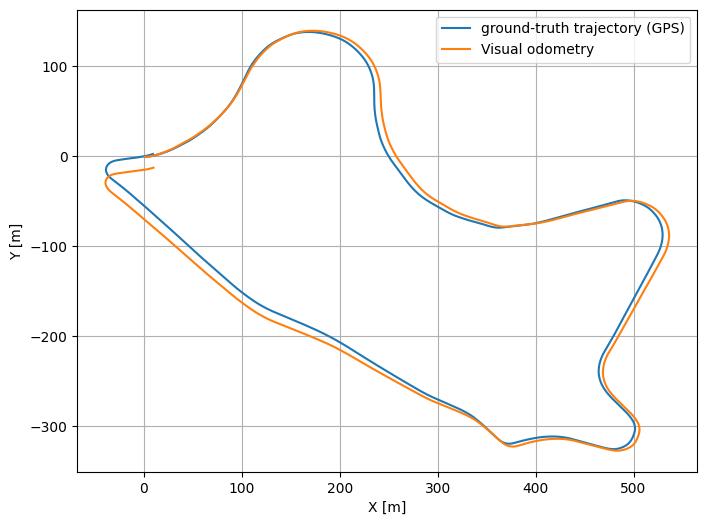

In [2]:
root_path = '../../../../'
kitti_root_dir = os.path(root_path, 'data')
vo_root_dir = os.path(root_path, 'vo_estimates')
noise_vector_dir = os.path(root_path, 'exports/_noise_optimizations/noise_vectors')
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

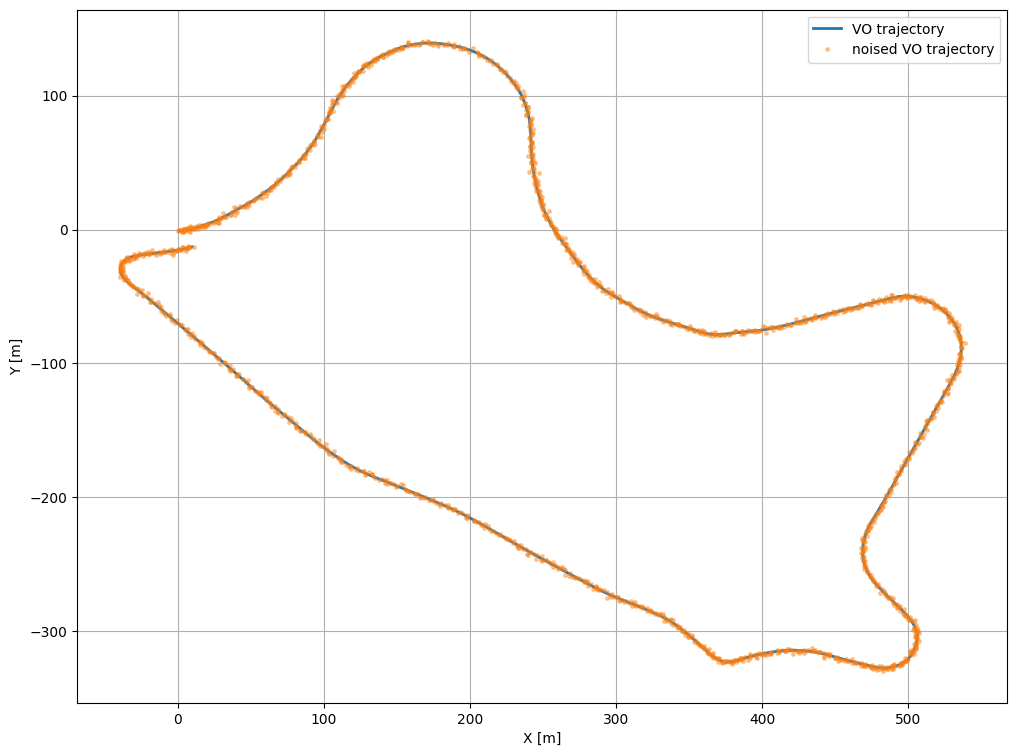

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

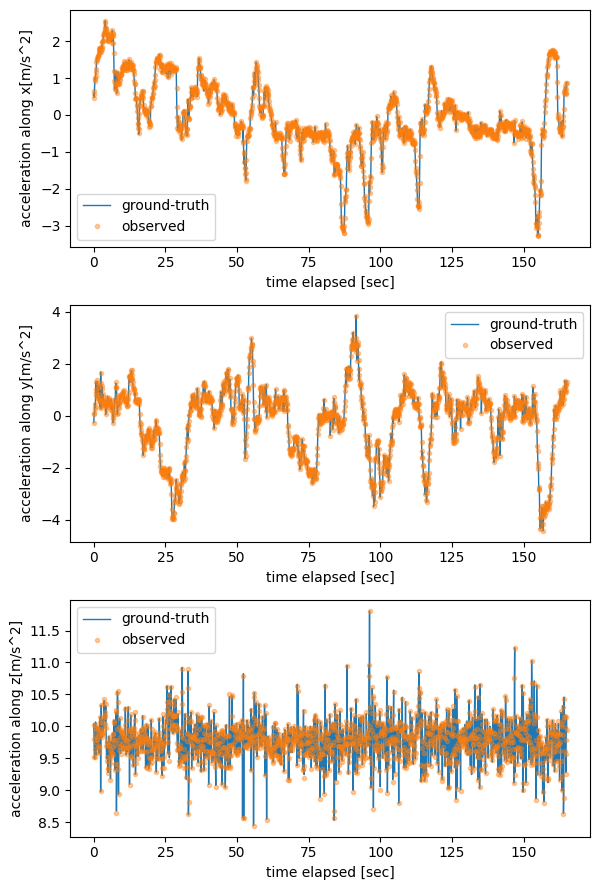

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

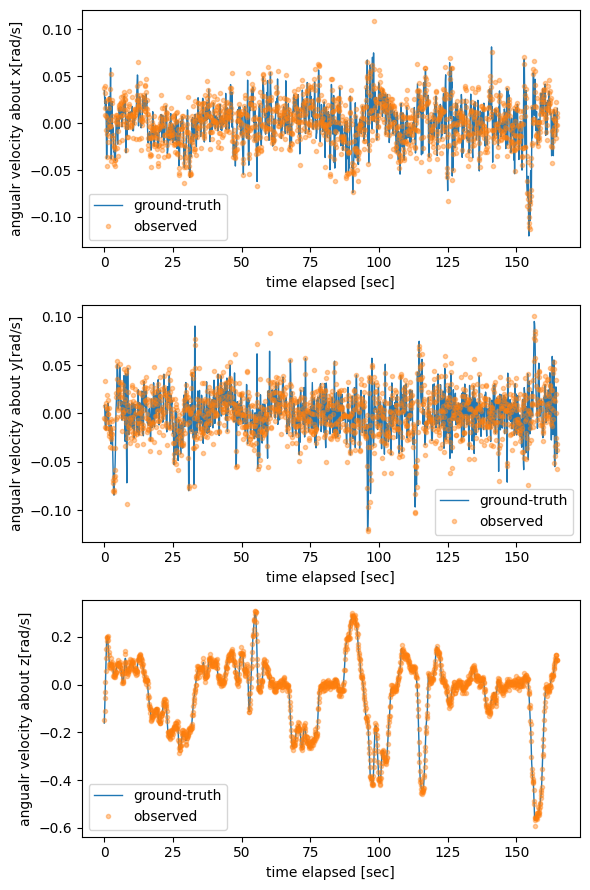

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

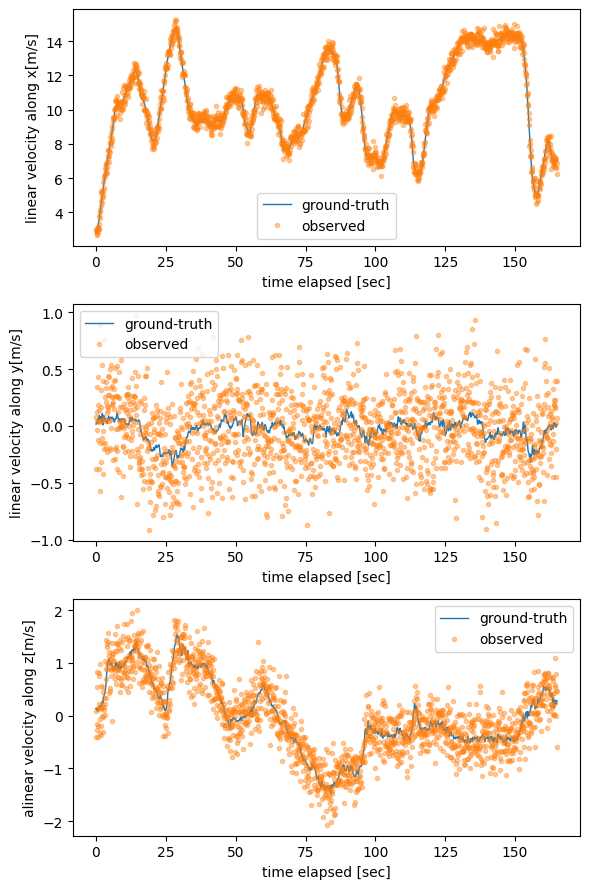

In [6]:
data.show_linear_velocity_with_noise()

# Applying Extended Kalman Filter

In [7]:
mae_errors = []
rmse_errors = []
max_errors = []

mae_vo = np.absolute(np.subtract(data.GPS_measurements_in_meter.T[:2, :], 
                                 data.VO_measurements.T[:2, :]))
rmse_vo = np.sqrt(mean_squared_error(data.GPS_measurements_in_meter.T[:2, :], 
                                      data.VO_measurements.T[:2, :]))
max_vo = np.max(mae_vo)

print(f"MAE: {np.mean(mae_vo)}")
print(f"RMSE: {rmse_vo}")
print(f"MAX: {max_vo}")
mae_errors.append(np.round(np.mean(mae_vo), Configs.decimal_place))
rmse_errors.append(np.round(rmse_vo, Configs.decimal_place))
max_errors.append(np.round(max_vo, Configs.decimal_place))

MAE: 3.8204236798597773
RMSE: 5.448548458980544
MAX: 15.244254650508374


--------------

## Setup1 (IMU input -> EKF with Visual Odometry measurement)

In [8]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=SetupEnum.SETUP_1, 
  filter_type=FilterEnum.EKF,
  noise_type=NoiseTypeEnum.CURRENT
)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 11966.59it/s]


----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.904 m
Root Mean Squared Error: 5.486 m
Maximum Error: 16.056 m
---------------------------------------------------



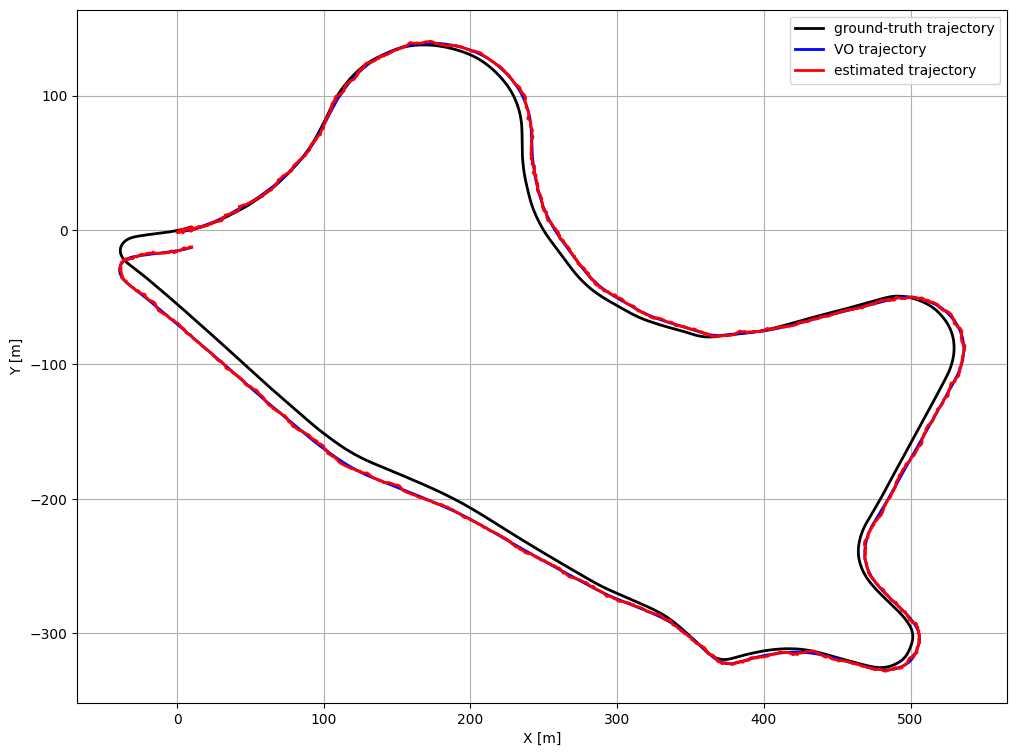

In [9]:
ekf1_0 = ExtendedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1
)
error_ekf1_0 = ekf1_0.run(
    data=data, 
    measurement_type=MeasurementDataEnum.ALL_DATA, 
    debug_mode=True,
    show_graph=True,
)

### Setup1 Result

In [10]:
print(f"MAE: {error_ekf1_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_ekf1_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_ekf1_0[ErrorEnum.MAX]}")

mae_errors.append(error_ekf1_0[ErrorEnum.MAE])
rmse_errors.append(error_ekf1_0[ErrorEnum.RMSE])
max_errors.append(error_ekf1_0[ErrorEnum.MAX])

MAE: 3.904
RMSE: 5.486
MAX: 16.056


## Setup2 (IMU input -> EKF with Visual Odometry and GPS measurement)

In [11]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=SetupEnum.SETUP_2, 
  filter_type=FilterEnum.EKF, 
  noise_type=NoiseTypeEnum.CURRENT
)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10038.84it/s]


----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.99 m
Root Mean Squared Error: 2.762 m
Maximum Error: 8.483 m
-------------------------------------------------------



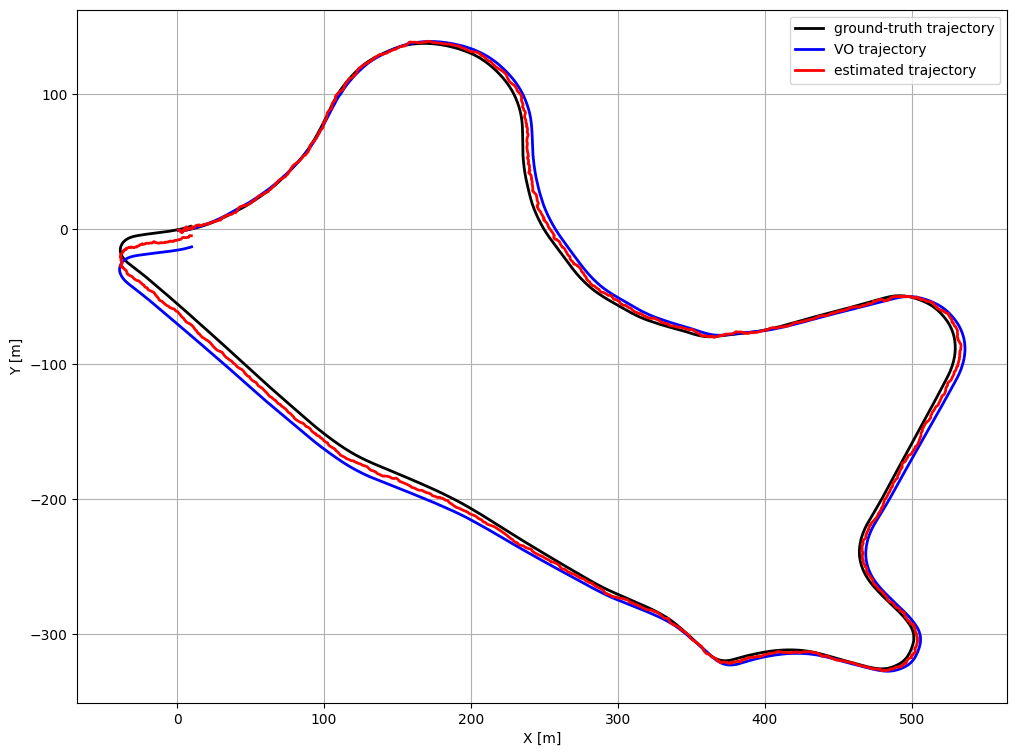

In [12]:
ekf2_0 = ExtendedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2
    )
error_ekf2_0 = ekf2_0.run(
    data=data, 
    measurement_type=MeasurementDataEnum.ALL_DATA, 
    debug_mode=True,
    show_graph=True,
)

### Setup2 Result

In [13]:
print(f"MAE: {error_ekf2_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_ekf2_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_ekf2_0[ErrorEnum.MAX]}")

mae_errors.append(error_ekf2_0[ErrorEnum.MAE])
rmse_errors.append(error_ekf2_0[ErrorEnum.RMSE])
max_errors.append(error_ekf2_0[ErrorEnum.MAX])

MAE: 1.99
RMSE: 2.762
MAX: 8.483


## Setup3 (INS input -> EKF with Visual Odometry and INS measurement)

In [14]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 17227.20it/s]


----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.948 m
Root Mean Squared Error: 2.737 m
Maximum Error: 8.202 m
-----------------------------------------------



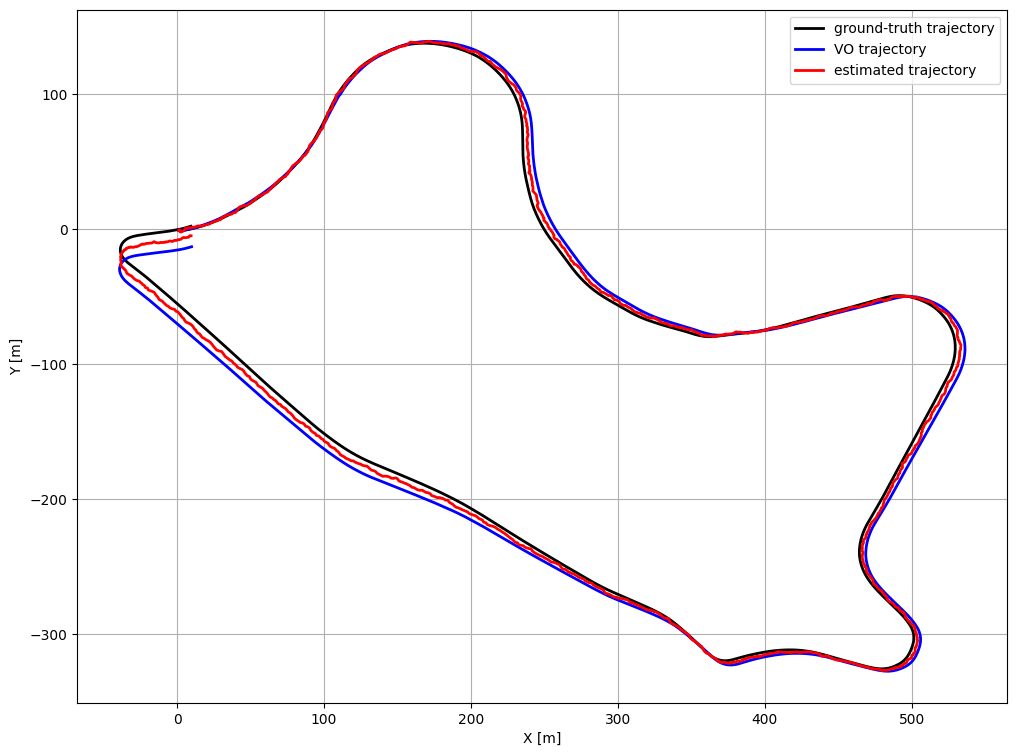

In [15]:
ekf3_0 = ExtendedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3
)
error_ekf3_0 = ekf3_0.run(
    data=data, 
    measurement_type=MeasurementDataEnum.ALL_DATA, 
    debug_mode=True,
    show_graph=True,
)

### Setup3 Result

In [16]:
print(f"MAE: {error_ekf3_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_ekf3_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_ekf3_0[ErrorEnum.MAX]}")

mae_errors.append(error_ekf3_0[ErrorEnum.MAE])
rmse_errors.append(error_ekf3_0[ErrorEnum.RMSE])
max_errors.append(error_ekf3_0[ErrorEnum.MAX])

MAE: 1.948
RMSE: 2.737
MAX: 8.202


# Result

In [17]:
errors = np.concatenate([mae_errors, rmse_errors, max_errors], axis=0).reshape(3, 4)
errors

array([[ 3.82 ,  3.904,  1.99 ,  1.948],
       [ 5.449,  5.486,  2.762,  2.737],
       [15.244, 16.056,  8.483,  8.202]])

In [19]:
error_labels = ["VO error", "EKF (IMU, VO)", 
                "EKF (IMU, VO + GPS)", "EKF (INS, VO + INS)"]
indices = ["MAE", "RMSE", "MAX"]
pd.DataFrame(errors, columns=error_labels, index=indices)

,VO error,"EKF (IMU, VO)","EKF (IMU, VO + GPS)","EKF (INS, VO + INS)"
MAE,3.820,3.904,1.990,1.948
RMSE,5.449,5.486,2.762,2.737
MAX,15.244,16.056,8.483,8.202
